In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# Load phase2 outputs — phase3 builds on top of these
df        = pd.read_csv("df_engineered.csv")
cluster_df = pd.read_csv("cluster_data.csv")
hotspot_df = pd.read_csv("hotspot_report.csv")

# Parse datetime
df["created_datetime"] = pd.to_datetime(df["created_datetime"], utc=True, errors="coerce")
# keep `date` as a normalized datetime64 (midnight) to preserve tz-awareness
df["date"] = pd.to_datetime(df["created_datetime"]).dt.normalize()
# Use pandas nullable integer dtype for week to allow missing datetimes (NA) without raising
df["week"] = pd.to_datetime(df["created_datetime"]).dt.isocalendar().week.astype("Int64")

print(f"Loaded {len(df):,} rows")
print(f"Clusters: {cluster_df['cluster'].nunique()}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")

Loaded 298,450 rows
Clusters: 869
Date range: 2023-11-09 00:00:00+00:00 → 2024-04-08 00:00:00+00:00


In [2]:
# ── LAYER 1: Historical Pattern Forecast ─────────────────────────
# For every cluster, build a 24 (hour) x 7 (weekday) matrix
# of average violation count. This IS the baseline forecast.

df_c = df[df["cluster"] != -1].copy()

pattern_matrix = (
    df_c.groupby(["cluster", "day_of_week", "hour"])
    .size()
    .reset_index(name="violation_count")
)

# How many weeks of data do we have? Use this to get weekly average
n_weeks = df_c["week"].nunique()
pattern_matrix["avg_per_week"] = (pattern_matrix["violation_count"] / n_weeks).round(2)

# Compute 75th percentile threshold per cluster
# Anything above this is considered a HIGH activity slot
thresholds = (
    pattern_matrix.groupby("cluster")["avg_per_week"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"avg_per_week": "threshold_75"})
)
pattern_matrix = pattern_matrix.merge(thresholds, on="cluster", how="left")
pattern_matrix["is_high_slot"] = (
    pattern_matrix["avg_per_week"] >= pattern_matrix["threshold_75"]
).astype(int)

DAY_NAMES = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
pattern_matrix["day_name"] = pattern_matrix["day_of_week"].map(DAY_NAMES)

print(f"Pattern matrix shape: {pattern_matrix.shape}")
print(f"\nSample — top 10 highest activity slots:")
print(
    pattern_matrix.sort_values("avg_per_week", ascending=False)
    [["cluster","day_name","hour","avg_per_week","is_high_slot"]]
    .head(10)
    .to_string(index=False)
)

Pattern matrix shape: (20656, 8)

Sample — top 10 highest activity slots:
 cluster day_name  hour  avg_per_week  is_high_slot
       1      Sun     4         57.39             1
       1      Sun     3         51.57             1
       1      Sun     5         48.48             1
       1      Tue     3         48.30             1
       1      Tue     4         46.57             1
       1      Sat     3         46.09             1
       2      Sun     5         45.87             1
       2      Sun     4         43.61             1
       1      Thu     3         41.70             1
       1      Thu     4         40.43             1


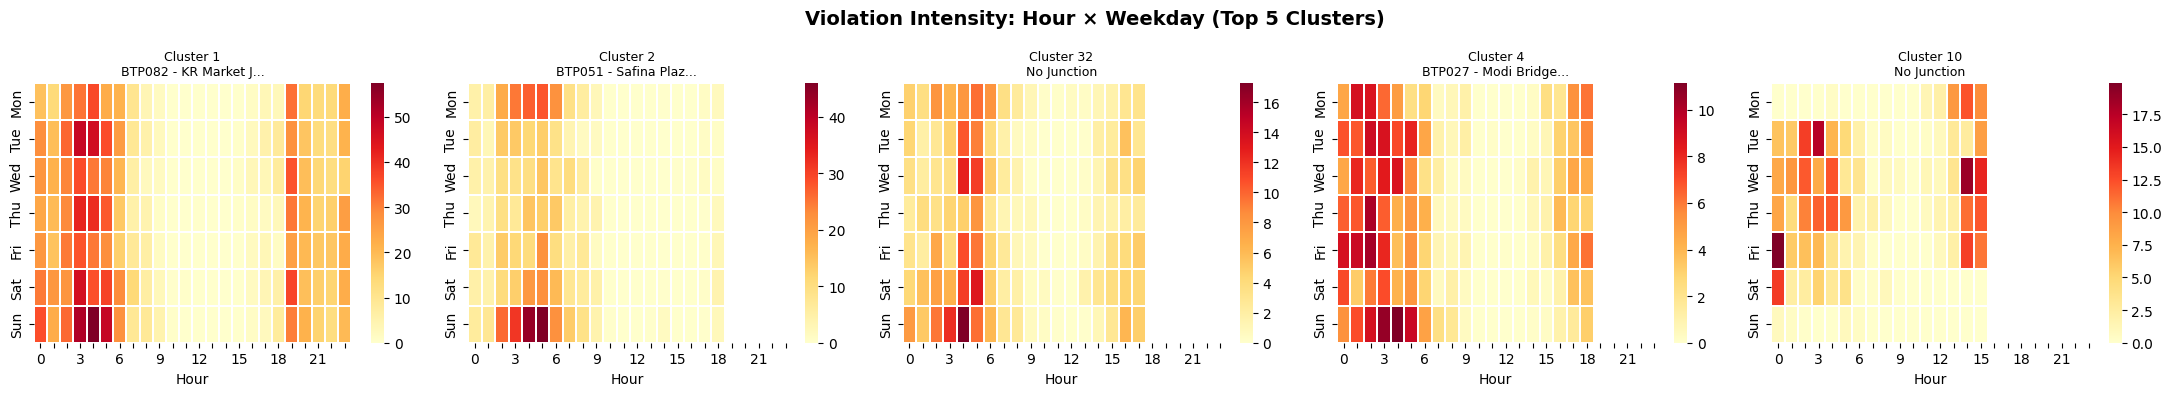

Saved → pattern_heatmaps.png


In [3]:
# Visualise the 24x7 heatmap for top 5 clusters by violation count
top5_clusters = (
    cluster_df.sort_values("violation_count", ascending=False)
    .head(5)["cluster"].tolist()
)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle("Violation Intensity: Hour × Weekday (Top 5 Clusters)", fontsize=14, fontweight="bold")

for ax, cid in zip(axes, top5_clusters):
    sub = pattern_matrix[pattern_matrix["cluster"] == cid]
    pivot = sub.pivot_table(
        index="day_of_week", columns="hour",
        values="avg_per_week", fill_value=0
    ).reindex(index=range(7), fill_value=0)
    pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

    junc = cluster_df[cluster_df["cluster"] == cid]["top_junction"].values[0]
    label = str(junc)[:20] + "..." if len(str(junc)) > 20 else str(junc)

    sns.heatmap(
        pivot, ax=ax, cmap="YlOrRd",
        cbar=True, linewidths=0.3,
        xticklabels=[str(h) if h % 3 == 0 else "" for h in range(24)]
    )
    ax.set_title(f"Cluster {cid}\n{label}", fontsize=9)
    ax.set_xlabel("Hour")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("pattern_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → pattern_heatmaps.png")

In [4]:
# ── Generate forecast for next 7 calendar days ───────────────────
# We simulate "today" as the day after the last date in the dataset
import datetime

last_date = pd.Timestamp(df["date"].max())
forecast_dates = [last_date + datetime.timedelta(days=i+1) for i in range(7)]

rows = []
for fdate in forecast_dates:
    dow = fdate.dayofweek
    day_name = DAY_NAMES[dow]
    is_weekend = int(dow >= 5)

    day_pattern = pattern_matrix[pattern_matrix["day_of_week"] == dow].copy()

    for _, row in day_pattern.iterrows():
        rows.append({
            "forecast_date":    fdate.date(),
            "day_name":         day_name,
            "is_weekend":       is_weekend,
            "cluster":          int(row["cluster"]),
            "hour":             int(row["hour"]),
            "predicted_violations": row["avg_per_week"],
            "is_high_slot":     int(row["is_high_slot"]),
            "threshold_75":     row["threshold_75"],
        })

pattern_forecast = pd.DataFrame(rows)

# Attach cluster metadata
pattern_forecast = pattern_forecast.merge(
    cluster_df[["cluster","top_junction","risk_score","risk_tier","center_lat","center_lon"]],
    on="cluster", how="left"
)

print(f"Pattern forecast rows: {len(pattern_forecast):,}")
print(f"\nForecast dates: {pattern_forecast['forecast_date'].unique()}")
print(f"\nHigh-activity slots forecast:")
print(
    pattern_forecast[pattern_forecast["is_high_slot"] == 1]
    .sort_values(["forecast_date","predicted_violations"], ascending=[True,False])
    [["forecast_date","day_name","hour","cluster","top_junction","predicted_violations","risk_tier"]]
    .head(15)
    .to_string(index=False)
)

Pattern forecast rows: 20,656

Forecast dates: [datetime.date(2024, 4, 9) datetime.date(2024, 4, 10)
 datetime.date(2024, 4, 11) datetime.date(2024, 4, 12)
 datetime.date(2024, 4, 13) datetime.date(2024, 4, 14)
 datetime.date(2024, 4, 15)]

High-activity slots forecast:
forecast_date day_name  hour  cluster                     top_junction  predicted_violations  risk_tier
   2024-04-09      Tue     3        1      BTP082 - KR Market Junction                 48.30 🔴 CRITICAL
   2024-04-09      Tue     4        1      BTP082 - KR Market Junction                 46.57 🔴 CRITICAL
   2024-04-09      Tue     5        1      BTP082 - KR Market Junction                 36.30 🔴 CRITICAL
   2024-04-09      Tue     2        1      BTP082 - KR Market Junction                 33.04 🔴 CRITICAL
   2024-04-09      Tue     0        1      BTP082 - KR Market Junction                 28.26 🔴 CRITICAL
   2024-04-09      Tue    19        1      BTP082 - KR Market Junction                 27.78 🔴 CRITICAL
 

In [5]:
# ── LAYER 3: Spike Classifier ─────────────────────────────────────
# Target: will a cluster-day have violations > its 75th percentile?
# Features: temporal + rolling statistics

# Step 1 — Daily aggregation per cluster
daily = (
    df_c.groupby(["cluster", "date"])
    .agg(
        daily_count      = ("id", "count"),
        avg_priority     = ("priority_score", "mean"),
        peak_hour_frac   = ("is_peak_hour", "mean"),
        is_weekend       = ("is_weekend", "first"),
        day_of_week      = ("day_of_week", "first"),
        week             = ("week", "first"),
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily = daily.sort_values(["cluster", "date"]).reset_index(drop=True)

# Step 2 — Rolling features (per cluster, last 7 days)
daily["rolling_7_mean"] = (
    daily.groupby("cluster")["daily_count"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)
daily["rolling_7_std"] = (
    daily.groupby("cluster")["daily_count"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).std().fillna(0))
)
daily["rolling_7_max"] = (
    daily.groupby("cluster")["daily_count"]
    .transform(lambda x: x.shift(1).rolling(7, min_periods=1).max())
)

# Step 3 — Target: is today a spike day for this cluster?
cluster_75 = (
    daily.groupby("cluster")["daily_count"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"daily_count": "cluster_p75"})
)
daily = daily.merge(cluster_75, on="cluster", how="left")
daily["will_spike"] = (daily["daily_count"] >= daily["cluster_p75"]).astype(int)

# Step 4 — Encode cluster as category feature
le = LabelEncoder()
daily["cluster_enc"] = le.fit_transform(daily["cluster"].astype(str))

print(f"Daily dataset: {len(daily):,} rows")
print(f"\nSpike rate: {daily['will_spike'].mean()*100:.1f}% of cluster-days are spikes")
print(f"\nFeature preview:")
print(daily[[
    "cluster","date","daily_count","rolling_7_mean",
    "rolling_7_std","will_spike"
]].head(10).to_string(index=False))

Daily dataset: 23,244 rows

Spike rate: 31.7% of cluster-days are spikes

Feature preview:
 cluster                      date  daily_count  rolling_7_mean  rolling_7_std  will_spike
       0 2023-11-16 00:00:00+00:00           16             NaN       0.000000           1
       0 2023-11-18 00:00:00+00:00           24       16.000000       0.000000           1
       0 2023-11-19 00:00:00+00:00            2       20.000000       5.656854           0
       0 2023-11-21 00:00:00+00:00            2       14.000000      11.135529           0
       0 2023-11-23 00:00:00+00:00            2       11.000000      10.893423           0
       0 2023-11-26 00:00:00+00:00            1        9.200000      10.256705           0
       0 2023-11-29 00:00:00+00:00            1        7.833333       9.765586           0
       0 2023-11-30 00:00:00+00:00            6        6.857143       9.281318           0
       0 2023-12-02 00:00:00+00:00            3        5.428571       8.363754           0

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    No Spike       0.68      0.70      0.69      2740
       Spike       0.51      0.49      0.50      1735

    accuracy                           0.62      4475
   macro avg       0.60      0.59      0.59      4475
weighted avg       0.62      0.62      0.62      4475



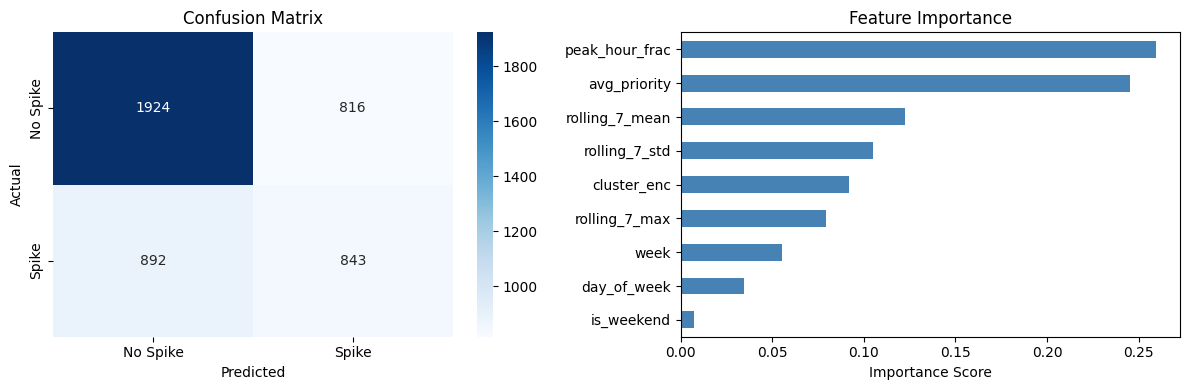

Saved → model_evaluation.png


In [6]:
# ── Train / Evaluate ──────────────────────────────────────────────

FEATURES = [
    "cluster_enc",
    "day_of_week",
    "is_weekend",
    "week",
    "avg_priority",
    "peak_hour_frac",
    "rolling_7_mean",
    "rolling_7_std",
    "rolling_7_max",
]
TARGET = "will_spike"

model_df = daily[FEATURES + [TARGET]].dropna()

X = model_df[FEATURES]
y = model_df[TARGET]

# Temporal split — train on first 80% of time, test on last 20%
# Never use random split for time series — it leaks future into past
split_idx = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight="balanced",   # handles imbalanced spike/no-spike
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=["No Spike","Spike"]))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Spike","Spike"],
            yticklabels=["No Spike","Spike"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
importances.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → model_evaluation.png")

In [7]:
# ── Generate spike predictions for next 7 days ────────────────────

pred_rows = []

for fdate in forecast_dates:
    dow        = fdate.dayofweek
    is_weekend = int(dow >= 5)
    week_num   = fdate.isocalendar()[1]

    for cid in daily["cluster"].unique():
        # Get last 7 days of data for this cluster for rolling features
        hist = daily[daily["cluster"] == cid].sort_values("date")

        if len(hist) == 0:
            continue

        roll_mean = hist["daily_count"].tail(7).mean()
        roll_std  = hist["daily_count"].tail(7).std() or 0
        roll_max  = hist["daily_count"].tail(7).max()
        avg_pri   = hist["avg_priority"].tail(7).mean()
        ph_frac   = hist["peak_hour_frac"].tail(7).mean()
        cenc      = le.transform([str(cid)])[0]

        pred_rows.append({
            "forecast_date":  fdate.date(),
            "day_name":       DAY_NAMES[dow],
            "is_weekend":     is_weekend,
            "cluster":        cid,
            "cluster_enc":    cenc,
            "day_of_week":    dow,
            "week":           week_num,
            "avg_priority":   avg_pri,
            "peak_hour_frac": ph_frac,
            "rolling_7_mean": roll_mean,
            "rolling_7_std":  roll_std,
            "rolling_7_max":  roll_max,
        })

pred_df = pd.DataFrame(pred_rows)
pred_df["spike_probability"] = rf.predict_proba(pred_df[FEATURES])[:, 1]
pred_df["spike_probability"] = pred_df["spike_probability"].round(3)
pred_df["predicted_spike"]   = (pred_df["spike_probability"] >= 0.5).astype(int)

# Attach cluster metadata
pred_df = pred_df.merge(
    cluster_df[["cluster","top_junction","risk_score","risk_tier","center_lat","center_lon"]],
    on="cluster", how="left"
)

# Alert level based on spike probability
def alert_level(p):
    if p >= 0.80: return "🔴 CRITICAL"
    if p >= 0.60: return "🟠 HIGH"
    if p >= 0.40: return "🟡 MEDIUM"
    return               "🟢 LOW"

pred_df["alert_level"] = pred_df["spike_probability"].apply(alert_level)

print(f"Spike predictions generated: {len(pred_df):,}")
print(f"\nTop 15 highest-risk cluster-days:")
print(
    pred_df.sort_values("spike_probability", ascending=False)
    [["forecast_date","day_name","cluster","top_junction","spike_probability","alert_level"]]
    .head(15)
    .to_string(index=False)
)

Spike predictions generated: 6,083

Top 15 highest-risk cluster-days:
forecast_date day_name  cluster                        top_junction  spike_probability alert_level
   2024-04-14      Sun      310                         No Junction              0.931  🔴 CRITICAL
   2024-04-12      Fri      310                         No Junction              0.928  🔴 CRITICAL
   2024-04-11      Thu      310                         No Junction              0.924  🔴 CRITICAL
   2024-04-13      Sat      310                         No Junction              0.924  🔴 CRITICAL
   2024-04-12      Fri      265                         No Junction              0.923  🔴 CRITICAL
   2024-04-10      Wed      310                         No Junction              0.922  🔴 CRITICAL
   2024-04-14      Sun      214 BTP117 - 9th Cross, Kanakapura Road              0.921  🔴 CRITICAL
   2024-04-14      Sun      348                         No Junction              0.921  🔴 CRITICAL
   2024-04-12      Fri      379      BT

=== WEEKLY FORECAST — TOP 20 CLUSTERS ===
forecast_date day_name                              top_junction  spike_probability alert_level
   2024-04-09      Tue                               No Junction              0.816  🔴 CRITICAL
   2024-04-09      Tue BTP148 - 17th Main, Doopanahalli Bus Stop              0.766      🟠 HIGH
   2024-04-09      Tue     BTP089 - Police Quarters, Sultan Road              0.754      🟠 HIGH
   2024-04-09      Tue                               No Junction              0.737      🟠 HIGH
   2024-04-09      Tue               BTP048 - Shanthala Junction              0.716      🟠 HIGH
   2024-04-09      Tue    BTP136 - Hosur-Tavarkere Road Junction              0.712      🟠 HIGH
   2024-04-09      Tue BTP148 - 17th Main, Doopanahalli Bus Stop              0.694      🟠 HIGH
   2024-04-09      Tue               BTP041 - Gopal Gowda Circle              0.664      🟠 HIGH
   2024-04-09      Tue BTP226 - 33rd Cross, 11th Main, Jayanagar              0.653      🟠 HIG

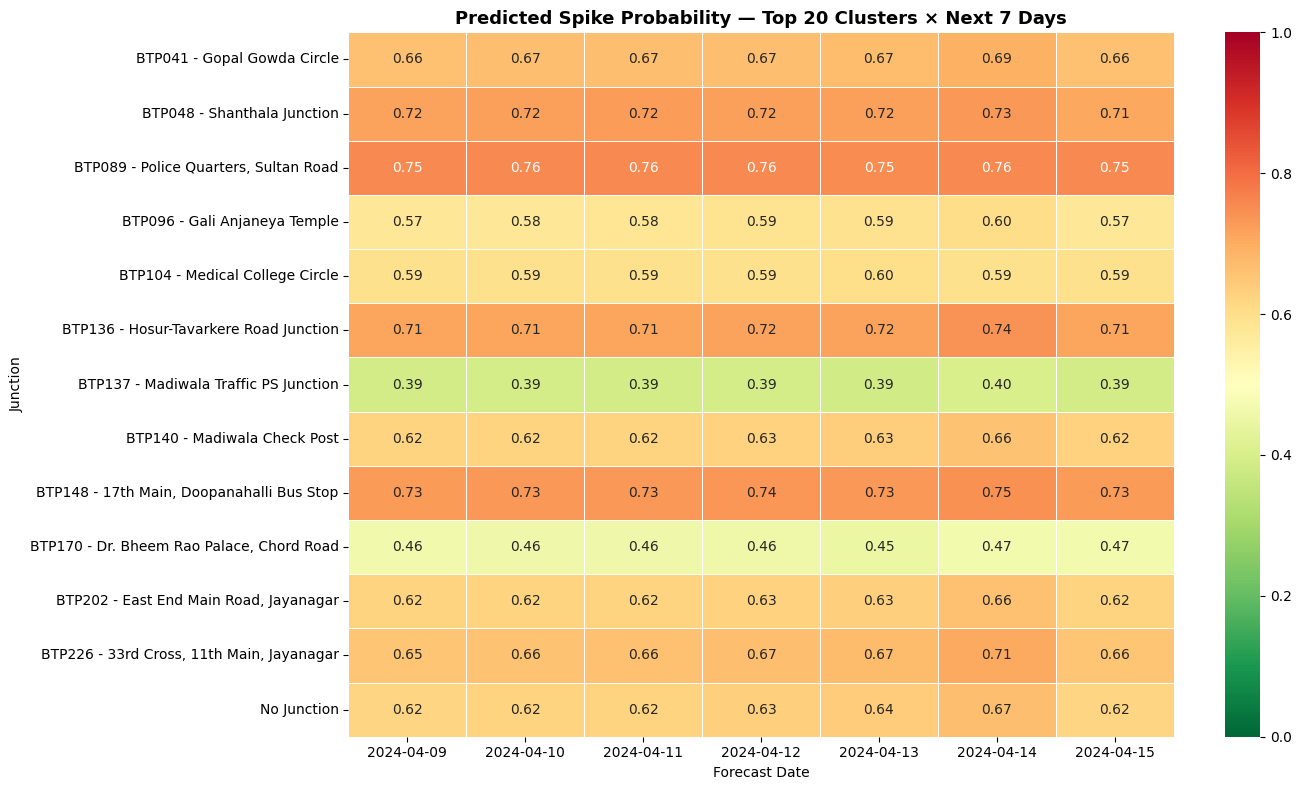

Saved → weekly_forecast_heatmap.png


In [8]:
# ── Weekly summary — best for dashboard display ───────────────────

weekly_summary = (
    pred_df.groupby(["cluster", "forecast_date", "day_name", "alert_level"])
    .agg(
        spike_probability = ("spike_probability", "max"),
        top_junction      = ("top_junction",      "first"),
        risk_score        = ("risk_score",         "first"),
        risk_tier         = ("risk_tier",          "first"),
        center_lat        = ("center_lat",         "first"),
        center_lon        = ("center_lon",         "first"),
    )
    .reset_index()
    .sort_values(["forecast_date","spike_probability"], ascending=[True, False])
)

# Focus on top 20 clusters for the dashboard
top20 = cluster_df.sort_values("risk_score", ascending=False).head(20)["cluster"].tolist()
weekly_top = weekly_summary[weekly_summary["cluster"].isin(top20)].copy()

print("=== WEEKLY FORECAST — TOP 20 CLUSTERS ===")
print(weekly_top[["forecast_date","day_name","top_junction","spike_probability","alert_level"]]
      .head(20).to_string(index=False))

# Visualise — heatmap of spike prob: clusters × forecast days
pivot_pred = weekly_top.pivot_table(
    index="top_junction",
    columns="forecast_date",
    values="spike_probability",
    fill_value=0
)
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_pred, cmap="RdYlGn_r",
    annot=True, fmt=".2f",
    linewidths=0.4,
    vmin=0, vmax=1,
    ax=ax
)
ax.set_title("Predicted Spike Probability — Top 20 Clusters × Next 7 Days", fontsize=13, fontweight="bold")
ax.set_xlabel("Forecast Date")
ax.set_ylabel("Junction")
plt.tight_layout()
plt.savefig("weekly_forecast_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → weekly_forecast_heatmap.png")

In [9]:
# ── Tomorrow's deployment briefing ───────────────────────────────
# This is the final output shown to traffic police

tomorrow = forecast_dates[0].date()
tomorrow_df = pred_df[pred_df["forecast_date"] == tomorrow].copy()
tomorrow_df = tomorrow_df[tomorrow_df["predicted_spike"] == 1].copy()
tomorrow_df = tomorrow_df.sort_values("spike_probability", ascending=False)

# Merge peak hour from pattern forecast for tomorrow
dow_tomorrow = forecast_dates[0].dayofweek
# Primary: peak hour for tomorrow's specific day-of-week
peak_hours_dow = (
    pattern_matrix[pattern_matrix["day_of_week"] == dow_tomorrow]
    .sort_values("avg_per_week", ascending=False)
    .groupby("cluster")["hour"].first()
    .reset_index()
    .rename(columns={"hour": "recommended_deploy_hour"})
)

# Fallback: overall peak hour per cluster (across all days)
peak_hours_overall = (
    pattern_matrix
    .sort_values("avg_per_week", ascending=False)
    .groupby("cluster")["hour"].first()
    .reset_index()
    .rename(columns={"hour": "recommended_deploy_hour_fallback"})
)

# Merge both, use fallback only where primary is missing
tomorrow_df = tomorrow_df.merge(peak_hours_dow, on="cluster", how="left")
tomorrow_df = tomorrow_df.merge(peak_hours_overall, on="cluster", how="left")

tomorrow_df["recommended_deploy_hour"] = (
    tomorrow_df["recommended_deploy_hour"]
    .fillna(tomorrow_df["recommended_deploy_hour_fallback"])
    .fillna(8)          # last resort only — means cluster has zero pattern data at all
    .astype(int)
)

tomorrow_df.drop(columns=["recommended_deploy_hour_fallback"], inplace=True)
# peak_hours = (
#     pattern_matrix[pattern_matrix["day_of_week"] == dow_tomorrow]
#     .sort_values("avg_per_week", ascending=False)
#     .groupby("cluster")["hour"].first()
#     .reset_index()
#     .rename(columns={"hour": "recommended_deploy_hour"})
# )
# tomorrow_df = tomorrow_df.merge(peak_hours, on="cluster", how="left")

def dispatch_action(row):
    p    = row["spike_probability"]
    hour = int(row.get("recommended_deploy_hour", 8))
    junc = row["top_junction"]
    if p >= 0.80:
        return f"🚨 DEPLOY 2+ units at {hour}:00. Tow zone activation. Priority: {junc}"
    elif p >= 0.60:
        return f"⚠️ DEPLOY 1 unit at {hour}:00. Issue penalties. Zone: {junc}"
    else:
        return f"👁️ MONITOR via CCTV at {hour}:00. Zone: {junc}"

tomorrow_df["dispatch_instruction"] = tomorrow_df.apply(dispatch_action, axis=1)

print(f"\n{'='*65}")
print(f"  DEPLOYMENT BRIEFING FOR {tomorrow} ({DAY_NAMES[dow_tomorrow].upper()})")
print(f"{'='*65}")
print(
    tomorrow_df[[
        "alert_level","spike_probability","top_junction",
        "recommended_deploy_hour","dispatch_instruction"
    ]]
    .head(20)
    .to_string(index=False)
)


  DEPLOYMENT BRIEFING FOR 2024-04-09 (TUE)
alert_level  spike_probability                             top_junction  recommended_deploy_hour                                                                                dispatch_instruction
 🔴 CRITICAL              0.911                              No Junction                        6                               🚨 DEPLOY 2+ units at 6:00. Tow zone activation. Priority: No Junction
 🔴 CRITICAL              0.909                              No Junction                       23                              🚨 DEPLOY 2+ units at 23:00. Tow zone activation. Priority: No Junction
 🔴 CRITICAL              0.907           BTP177 - Aurobindo Circle, ORR                        0            🚨 DEPLOY 2+ units at 0:00. Tow zone activation. Priority: BTP177 - Aurobindo Circle, ORR
 🔴 CRITICAL              0.903      BTP117 - 9th Cross, Kanakapura Road                       21      🚨 DEPLOY 2+ units at 21:00. Tow zone activation. Priority: BTP117 

In [10]:
# ── Export ────────────────────────────────────────────────────────

pattern_forecast.to_csv("pattern_forecast.csv", index=False)
print(f"pattern_forecast.csv     → {len(pattern_forecast):,} rows")

pred_df.to_csv("spike_predictions.csv", index=False)
print(f"spike_predictions.csv    → {len(pred_df):,} rows")

weekly_summary.to_csv("weekly_forecast.csv", index=False)
print(f"weekly_forecast.csv      → {len(weekly_summary):,} rows")

tomorrow_df.to_csv("dispatch_briefing.csv", index=False)
print(f"dispatch_briefing.csv    → {len(tomorrow_df):,} rows")

print("\n✅ Phase 3 complete. Outputs ready for Tab 6 in app.py:")
print("   pattern_forecast.csv")
print("   spike_predictions.csv")
print("   weekly_forecast.csv")
print("   dispatch_briefing.csv")
print("   pattern_heatmaps.png")
print("   model_evaluation.png")
print("   weekly_forecast_heatmap.png")

pattern_forecast.csv     → 20,656 rows
spike_predictions.csv    → 6,083 rows
weekly_forecast.csv      → 6,083 rows
dispatch_briefing.csv    → 662 rows

✅ Phase 3 complete. Outputs ready for Tab 6 in app.py:
   pattern_forecast.csv
   spike_predictions.csv
   weekly_forecast.csv
   dispatch_briefing.csv
   pattern_heatmaps.png
   model_evaluation.png
   weekly_forecast_heatmap.png
